# 04 · แผนที่ความเสี่ยงน้ำท่วมรายโซน

LSTM ใน notebook 03 ทำนายตัวเลขเดียว คือ **ระดับน้ำสูงสุดของ X.44** ใน 1–5 วันข้างหน้า
notebook นี้แปลงตัวเลขนั้นเป็น **แผนที่ว่าโซนไหนจะท่วม**

```
DEM 30 ม. ──► terrain features ──► LightGBM ความเสี่ยงรายจุด (เรียนจากน้ำท่วมจริง พ.ย. 2568)
                                            │  เรียงอันดับ (rank) ทั้งเมือง
                                            ▼
                         "ระดับวิกฤต": X.44 ต้องสูงเท่าไรจุดนี้จึงท่วม
                                            │
ระดับ X.44 ที่ LSTM ทำนาย ± ความคลาดเคลื่อน ──┴──► ความน่าจะเป็นท่วมรายโซน (H3) วันที่ +1 … +5
```

1. Terrain features จาก Copernicus DEM GLO-30: ความสูง, HAND (ความสูงเหนือลำน้ำที่ใกล้ที่สุด), พื้นที่รับน้ำ, ระยะห่างจากลำน้ำ, ความชัน
2. label: ขอบเขตน้ำท่วม EOS-RS 23 พ.ย. 2568 (จาก notebook 01)
3. เทียบตัวทำนายความเสี่ยง 3 แบบด้วย **spatial block cross-validation**
4. เรียงอันดับความเสี่ยงทั้งเมือง แล้วแปลงเป็น **ระดับวิกฤต** ของแต่ละจุด
5. รวมเป็นโซน H3 และคำนวณความน่าจะเป็นท่วมจากการพยากรณ์ของ LSTM → ไฟล์สำหรับหน้าเว็บ

In [1]:
import json
import warnings

import joblib

import geopandas
import lightgbm
import matplotlib.pyplot as plt
import numpy
import pandas
from IPython.display import display
from sklearn.metrics import roc_auc_score

from mojito import config, spatial

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "font.family": ["Noto Sans Thai", "DejaVu Sans"],
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
RAW = config.RAW_DIR
PROCESSED = config.DATA_DIR / "processed"
H3_RESOLUTION = 8  # ~0.74 km2 per zone

dem = spatial.open_dem(RAW / "dem_glo30.tif")
terrain = spatial.terrain_features(RAW / "dem_glo30.tif")
eosrs = geopandas.read_parquet(RAW / "eosrs_flood_2025.parquet")
hatyai = geopandas.read_file(config.RESOURCES_DIR / "hatyai_boundary.geojson")

flooded = spatial.rasterize(eosrs.geometry, dem)
in_hatyai = spatial.rasterize(hatyai.geometry, dem)
study = in_hatyai & numpy.isfinite(terrain["hand"])
lons, lats = numpy.meshgrid(dem.x.values, dem.y.values)
cell_km2 = spatial.cell_area_km2(dem)

print(f"ขนาดช่อง DEM: {dem.rio.resolution()[0] * 111_320:.0f} ม. (ตามแนวตะวันออก-ตะวันตก)")
print(f"พื้นที่ศึกษา (อ.หาดใหญ่): {study.sum() * cell_km2:,.0f} ตร.กม. ({study.sum():,} จุด 30 ม.)")
print(f"ท่วมตาม EOS-RS: {(flooded & study).sum() * cell_km2:,.1f} ตร.กม. ({flooded[study].mean():.1%})")

ขนาดช่อง DEM: 31 ม. (ตามแนวตะวันออก-ตะวันตก)
พื้นที่ศึกษา (อ.หาดใหญ่): 770 ตร.กม. (816,772 จุด 30 ม.)
ท่วมตาม EOS-RS: 69.9 ตร.กม. (9.1%)


## 1 · Terrain features จาก Copernicus DEM GLO-30
DEM ให้ความสูงทีละช่อง 30 × 30 ม. แล้ว `spatial.terrain_features` (pysheds) คำนวณทิศทางการไหลของน้ำบนผิวดิน ได้ 5 ค่าต่อช่อง

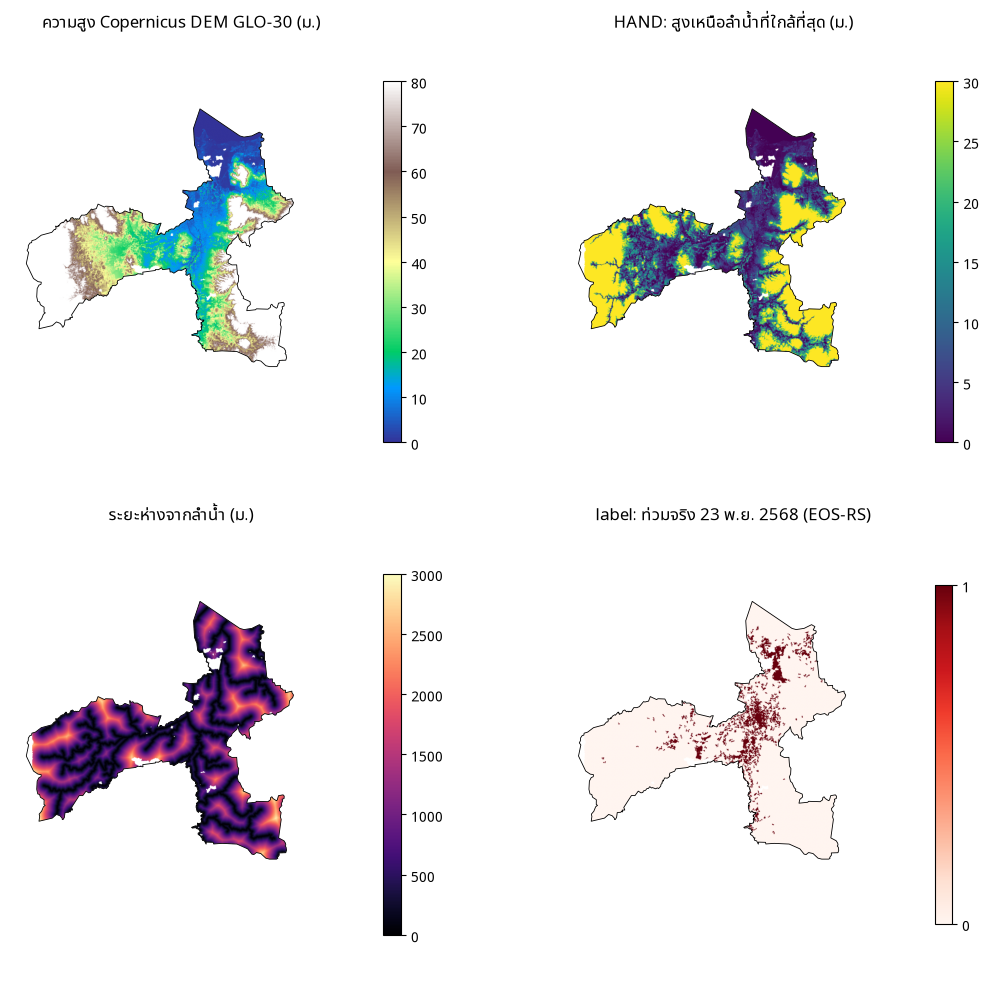

In [2]:
extent = [float(dem.x.min()), float(dem.x.max()), float(dem.y.min()), float(dem.y.max())]
panels = [
    ("elevation", "ความสูง Copernicus DEM GLO-30 (ม.)", "terrain", (0, 80)),
    ("hand", "HAND: สูงเหนือลำน้ำที่ใกล้ที่สุด (ม.)", "viridis", (0, 30)),
    ("drainage_distance", "ระยะห่างจากลำน้ำ (ม.)", "magma", (0, 3000)),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, title, cmap, (vmin, vmax)) in zip(axes.flat, panels):
    image = ax.imshow(numpy.where(study, terrain[name], numpy.nan), cmap=cmap, vmin=vmin, vmax=vmax, extent=extent)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, shrink=0.8)
image = axes[1, 1].imshow(numpy.where(study, flooded, numpy.nan), cmap="Reds", vmin=0, vmax=1, extent=extent)
axes[1, 1].set_title("label: ท่วมจริง 23 พ.ย. 2568 (EOS-RS)")
fig.colorbar(image, ax=axes[1, 1], shrink=0.75, ticks=[0, 1])
for ax in axes.flat:
    hatyai.boundary.plot(ax=ax, color="k", lw=0.6)
    ax.set_axis_off()
plt.tight_layout()
plt.show()

## 2 · เทียบตัวทำนายความเสี่ยงด้วย spatial block cross-validation
แบ่งพื้นที่เป็นบล็อก ~3×3 กม. สลับแบบกระดานหมากรุก แล้วสลับบทบาท train/test (2 fold)
— ถ้าสุ่มรายจุด จุดข้างเคียงที่แทบเหมือนกันจะรั่วเข้า test ทำให้ผลดูดีเกินจริง

ตัวชี้วัด: **AUC** (จัดลำดับจุดเสี่ยงได้ดีแค่ไหน) และ **CSI** = TP / (TP + FP + FN) ที่ threshold ดีที่สุด

In [3]:
BLOCK = 100  # cells (~3 km)
rows, cols = numpy.indices(dem.shape)
checker = ((rows // BLOCK + cols // BLOCK) % 2 == 0)
X_all = spatial.stack(terrain, study)
y_all = flooded[study]
fold = checker[study]

def best_csi(score, label):
    best = 0.0
    for threshold in numpy.quantile(score, numpy.linspace(0.5, 0.99, 50)):
        predicted = score >= threshold
        tp = (predicted & label).sum(); fp = (predicted & ~label).sum(); fn = (~predicted & label).sum()
        best = max(best, tp / (tp + fp + fn))
    return best

LGBM_PARAMS = dict(n_estimators=300, learning_rate=0.05, num_leaves=31, min_child_samples=200, verbose=-1, random_state=42)
comparison = {"ความสูงต่ำ (−elevation)": [], "HAND ต่ำ (−HAND)": [], "LightGBM (5 terrain features)": []}
for test_fold in (True, False):
    train_rows, test_rows = fold != test_fold, fold == test_fold
    classifier = lightgbm.LGBMClassifier(**LGBM_PARAMS).fit(X_all[train_rows], y_all[train_rows])
    scores = {
        "ความสูงต่ำ (−elevation)": -X_all[test_rows, 0],
        "HAND ต่ำ (−HAND)": -X_all[test_rows, 1],
        "LightGBM (5 terrain features)": classifier.predict_proba(X_all[test_rows])[:, 1],
    }
    for name, score in scores.items():
        comparison[name].append((roc_auc_score(y_all[test_rows], score), best_csi(score, y_all[test_rows])))

pandas.DataFrame({
    name: {"AUC": numpy.mean([v[0] for v in values]), "CSI": numpy.mean([v[1] for v in values])}
    for name, values in comparison.items()
}).T.round(3)

,AUC,CSI
ความสูงต่ำ (−elevation),0.841,0.252
HAND ต่ำ (−HAND),0.787,0.189
LightGBM (5 terrain features),0.896,0.307


LightGBM ดีกว่าการใช้ความสูงหรือ HAND อย่างเดียวเล็กน้อย ค่า CSI ที่ไม่สูงมาก (~0.3) ส่วนหนึ่งมาจาก label เอง —
EOS-RS เป็น flood *proxy* จาก change detection ที่มีทั้งน้ำท่วมที่ตรวจไม่พบ และจุดที่ไม่ได้ท่วมจริง (เช่นนาข้าวที่เปลี่ยนสภาพ)
จึงเป็นเพดานที่โมเดลใดๆ ก็ทำได้ไม่เกินมากนัก

## 3 · โมเดลความเสี่ยงสุดท้าย, อันดับความเสี่ยงทั้งเมือง และ "ระดับวิกฤต"
เทรน LightGBM บนทุกจุดในอำเภอหาดใหญ่ แล้ว **เรียงอันดับ** คะแนนความเสี่ยงของทุกจุด (rank 0 % = เสี่ยงที่สุดในเมือง)
จากนั้นแปลงอันดับเป็น **ระดับ X.44 ที่จุดนั้นเริ่มท่วม**
- ที่ระดับ 7.40 ม. (เริ่มท่วมพื้นที่ลุ่มต่ำ) ยังไม่มีจุดไหนท่วม
- ที่ระดับ 9.97 ม. (ยอดน้ำ 2568) จุดที่เสี่ยงที่สุด ~9% แรกท่วม = เท่ากับขอบเขตที่สังเกตได้จริง
  (ภาพถ่ายวันที่ 23 พ.ย. ตอน X.44 ~7.3–7.9 ม. ไม่ใช่วันพีค — ดูข้อจำกัดท้าย notebook)
- ระหว่างนั้นสัดส่วนพื้นที่ท่วมเพิ่มแบบเส้นตรง (**สมมติฐาน** — มีเหตุการณ์ที่มีแผนที่เพียงครั้งเดียว จึงยังพิสูจน์รูปร่างของเส้นนี้ไม่ได้)

,สัดส่วน gain
elevation,0.799
slope,0.072
hand,0.071
drainage_distance,0.047
log_accumulation,0.011


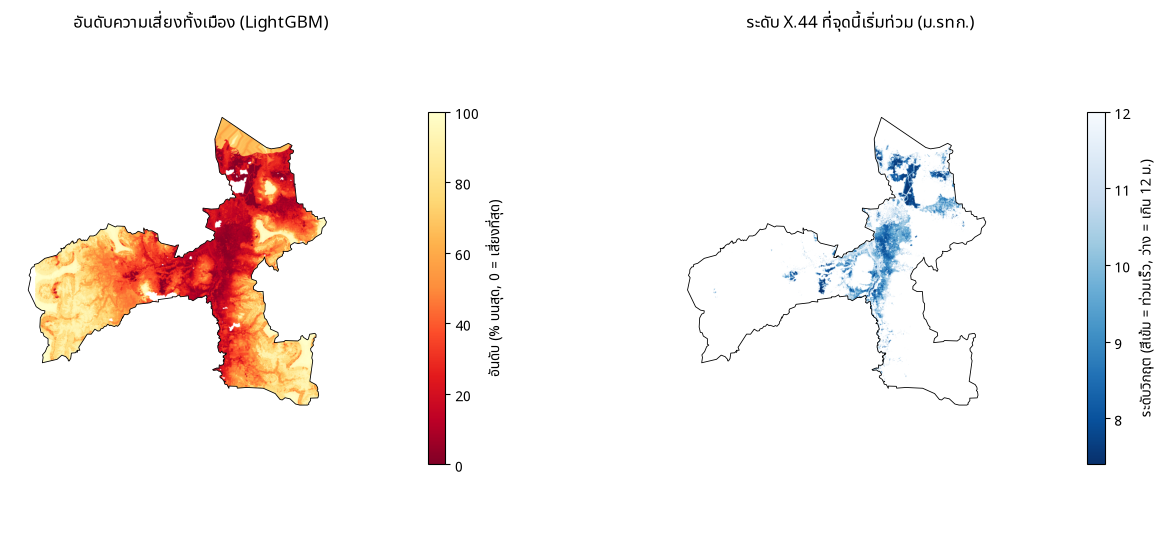

In [4]:
susceptibility_model = lightgbm.LGBMClassifier(**LGBM_PARAMS).fit(X_all, y_all)
susceptibility = susceptibility_model.predict_proba(X_all)[:, 1]
flooded_share_2025 = y_all.mean()
critical = spatial.critical_stage(susceptibility, flooded_share_2025)
rank_pct = pandas.Series(susceptibility).rank(ascending=False, pct=True).to_numpy() * 100

critical_map = numpy.full(dem.shape, numpy.nan)
critical_map[study] = critical
rank_map = numpy.full(dem.shape, numpy.nan)
rank_map[study] = rank_pct

importance = pandas.Series(
    susceptibility_model.booster_.feature_importance("gain"), index=spatial.TERRAIN_FEATURES
)
display((importance / importance.sum()).sort_values(ascending=False).round(3).to_frame("สัดส่วน gain"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
image = axes[0].imshow(rank_map, cmap="YlOrRd_r", vmin=0, vmax=100, extent=extent)
axes[0].set_title("อันดับความเสี่ยงทั้งเมือง (LightGBM)")
fig.colorbar(image, ax=axes[0], shrink=0.7, label="อันดับ (% บนสุด, 0 = เสี่ยงที่สุด)")
image = axes[1].imshow(numpy.where(critical_map <= 12, critical_map, numpy.nan), cmap="Blues_r", vmin=7.4, vmax=12, extent=extent)
axes[1].set_title("ระดับ X.44 ที่จุดนี้เริ่มท่วม (ม.รทก.)")
fig.colorbar(image, ax=axes[1], shrink=0.7, label="ระดับวิกฤต (สีเข้ม = ท่วมเร็ว, ว่าง = เกิน 12 ม.)")
for ax in axes:
    hatyai.boundary.plot(ax=ax, color="k", lw=0.6)
    ax.set_axis_off()
plt.tight_layout()
plt.show()

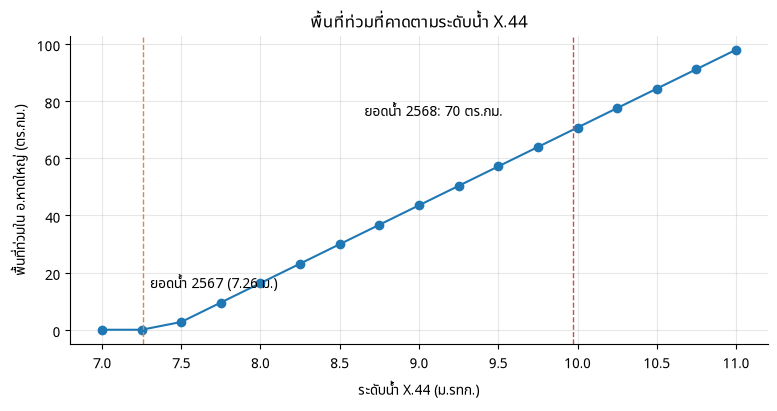

In [5]:
stages = numpy.arange(7.0, 11.01, 0.25)
area = [(critical <= s).sum() * cell_km2 for s in stages]
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(stages, area, marker="o")
ax.axvline(9.97, color="#c44e52", ls="--", lw=1)
ax.annotate(f"ยอดน้ำ 2568: {(critical <= 9.97).sum() * cell_km2:.0f} ตร.กม.", (9.97, (critical <= 9.97).sum() * cell_km2),
            xytext=(-150, 10), textcoords="offset points")
ax.axvline(7.26, color="#dd8452", ls="--", lw=1)
ax.annotate("ยอดน้ำ 2567 (7.26 ม.)", (7.26, 0), xytext=(5, 30), textcoords="offset points")
ax.set_xlabel("ระดับน้ำ X.44 (ม.รทก.)")
ax.set_ylabel("พื้นที่ท่วมใน อ.หาดใหญ่ (ตร.กม.)")
ax.set_title("พื้นที่ท่วมที่คาดตามระดับน้ำ X.44")
plt.show()

## 4 · รวมเป็นโซน H3 (ความละเอียด 8, ~0.74 ตร.กม./โซน)
แต่ละโซนเก็บ quantile ของระดับวิกฤตของจุดในโซน (5%, 15%, …, 95%)
เพื่อให้หน้าเว็บคำนวณ "สัดส่วนพื้นที่โซนที่คาดว่าจะท่วม" จากระดับที่ทำนายได้ทันที

In [6]:
zones = spatial.zone_table(critical, lats[study], lons[study], H3_RESOLUTION, observed=y_all)
zones["start_stage"] = zones["q05"]  # ระดับที่ 5% ของโซนเริ่มท่วม
zones["area_km2"] = zones["cells"] * cell_km2
print(f"{len(zones):,} โซน")
zones.drop(columns="geometry").describe().round(2).T[["mean", "min", "50%", "max"]]

1,010 โซน


,mean,min,50%,max
q05,17.98,7.40,18.75,35.61
q15,19.35,7.40,20.01,35.63
q25,20.22,7.41,20.62,35.65
q35,20.96,7.42,21.41,35.66
q45,21.59,7.62,22.10,35.66
q55,22.18,7.66,22.59,35.67
q65,22.79,7.71,23.30,35.67
q75,23.42,7.84,23.86,35.68
q85,24.16,8.19,24.90,35.69
q95,25.22,9.40,26.66,35.70


## 5 · ทดลองกับเหตุการณ์จริง: ออกพยากรณ์ ณ สิ้นวันที่ 21 พ.ย. 2568
ใช้ LSTM จาก notebook 03 (`x44_lstm.joblib`, เทรนถึงปี 2567 วันนี้อยู่ในชุด test) ทำนายระดับ X.44 วันที่ 22–26 พ.ย.
ด้วยพยากรณ์ฝน GFS ที่ปรับ bias แล้ว แปลงเป็นความน่าจะเป็นท่วมรายโซน โดยใช้ความคลาดเคลื่อนของ LSTM แยกตามระดับที่ทำนาย (`uncertainty.json` คีย์ `lstm`)
— ขั้นตอนเดียวกับที่หน้าเว็บใช้ (`mojito/web/forecast.py`)

In [7]:
table = pandas.read_parquet(PROCESSED / "minimal_daily.parquet")
models_dir = config.DATA_DIR / "models"
lstm_model = joblib.load(models_dir / "x44_lstm.joblib")
uncertainty = json.loads((models_dir / "uncertainty.json").read_text())

issue_day = pandas.Timestamp("2025-11-21")
stages = lstm_model.predict(table, [issue_day]).iloc[0]
forecast = []
for h in range(1, 6):
    stage = float(stages[f"h{h}"])
    sigma = spatial.forecast_sigma(uncertainty, "lstm", h, stage)
    probability = spatial.zone_flood_probability(zones, stage, sigma)
    forecast.append({
        "วันที่": (issue_day + pandas.Timedelta(days=h)).date(),
        "h": h,
        "X.44 ทำนาย (ม.)": round(stage, 2),
        "± σ (ม.)": round(sigma, 2),
        "X.44 จริง (ม.)": table["x44_max"].get(issue_day + pandas.Timedelta(days=h)),
        "โซนเสี่ยง ≥ 50%": int((probability >= 0.5).sum()),
        "พื้นที่ท่วมคาด (ตร.กม.)": round(float((probability * zones["area_km2"]).sum()), 1),
    })
    zones[f"prob_h{h}"] = probability.to_numpy()
pandas.DataFrame(forecast).set_index("วันที่")

,h,X.44 ทำนาย (ม.),± σ (ม.),X.44 จริง (ม.),โซนเสี่ยง ≥ 50%,พื้นที่ท่วมคาด (ตร.กม.)
วันที่,,,,,,
2025-11-22,1,6.92,0.91,7.910,0,4.5
2025-11-23,2,8.29,1.82,7.910,8,33.3
2025-11-24,3,8.70,2.43,9.420,15,47.0
2025-11-25,4,8.48,3.09,9.970,9,49.6
2025-11-26,5,8.44,3.89,9.285,8,57.3


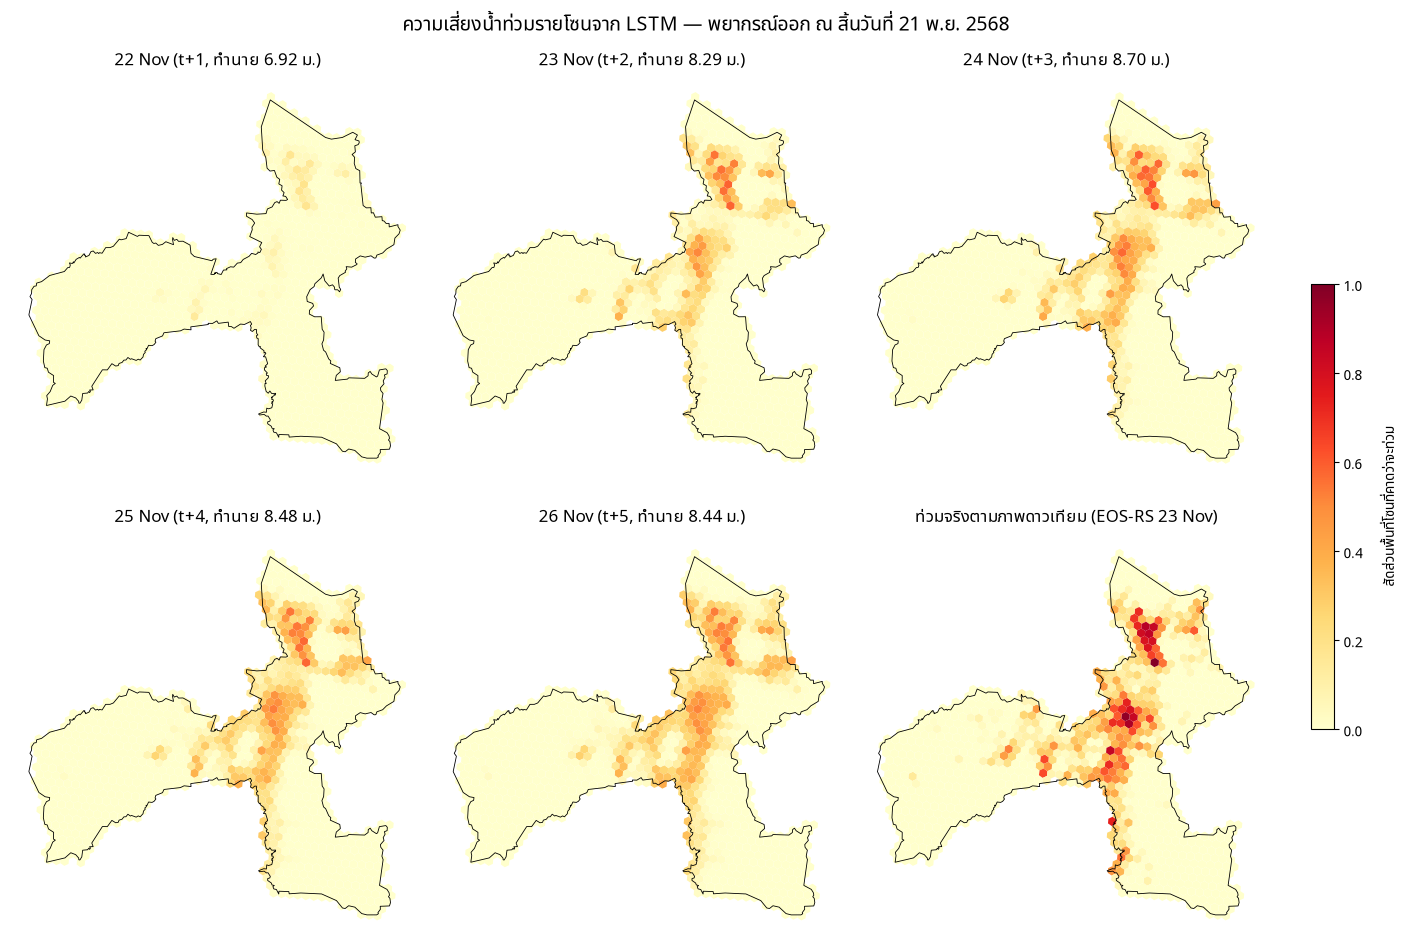

In [8]:
# 5 วันที่ทำนาย + ช่องสุดท้ายเป็นสัดส่วนที่ท่วมจริงตามภาพดาวเทียม 23 พ.ย. 2568 ไว้เทียบ
fig, axes = plt.subplots(2, 3, figsize=(14, 9.5), constrained_layout=True)
panels = [
    (f"prob_h{h}", f"{(issue_day + pandas.Timedelta(days=h)):%d %b} (t+{h}, ทำนาย {stages[f'h{h}']:.2f} ม.)")
    for h in range(1, 6)
] + [("flooded_share_2025", "ท่วมจริงตามภาพดาวเทียม (EOS-RS 23 Nov)")]
for ax, (column, title) in zip(axes.flat, panels):
    zones.plot(column=column, ax=ax, cmap="YlOrRd", vmin=0, vmax=1, linewidth=0)
    hatyai.boundary.plot(ax=ax, color="k", lw=0.6)
    ax.set_title(title)
    ax.set_axis_off()
colorbar = fig.colorbar(plt.cm.ScalarMappable(cmap="YlOrRd", norm=plt.Normalize(0, 1)), ax=axes, shrink=0.5, pad=0.03)
colorbar.set_label("สัดส่วนพื้นที่โซนที่คาดว่าจะท่วม", labelpad=12)
fig.suptitle("ความเสี่ยงน้ำท่วมรายโซนจาก LSTM — พยากรณ์ออก ณ สิ้นวันที่ 21 พ.ย. 2568", fontsize=14)
plt.show()

## 6 · บันทึกโซนสำหรับหน้าเว็บ
`data/processed/zones_h3.geojson` — เรขาคณิตโซน + quantile ระดับวิกฤต + ระดับที่เริ่มท่วม + สัดส่วนที่ท่วมจริงปี 2568
หน้าเว็บอ่านไฟล์นี้ แล้วคำนวณความน่าจะเป็นจากการพยากรณ์ล่าสุดด้วย `spatial.zone_flood_probability`

In [9]:
output = PROCESSED / "zones_h3.geojson"
zones.drop(columns=[c for c in zones.columns if c.startswith("prob_h")]).round(3).to_file(output, driver="GeoJSON")
print(f"saved {output.relative_to(config.ROOT)}: {len(zones):,} โซน, {output.stat().st_size / 1e6:.1f} MB")

saved data/processed/zones_h3.geojson: 1,010 โซน, 0.7 MB


## สรุป
- **โมเดลความเสี่ยงรายจุด (LightGBM, 5 terrain features)** แยกจุดท่วม/ไม่ท่วมได้ AUC ~0.90 บน spatial block CV
  ดีกว่าใช้ความสูง (0.84) หรือ HAND (0.79) อย่างเดียว — ความสูงเป็นปัจจัยหลัก (~80% ของ gain) สอดคล้องกับภูมิประเทศแอ่งกระทะของหาดใหญ่
- **อันดับความเสี่ยง → ระดับวิกฤต** ทำให้แผนที่ตอบสนองต่อการพยากรณ์ระดับน้ำ และอธิบายให้ประชาชนเข้าใจง่าย: "โซนนี้เริ่มท่วมเมื่อ X.44 สูงถึง … ม."
- **1,010 โซน H3** (~0.74 ตร.กม.) ครอบคลุม อ.หาดใหญ่ บันทึกใน `data/processed/zones_h3.geojson` พร้อมใช้ในหน้าเว็บ
- สาธิตด้วย LSTM ออกพยากรณ์ ณ 21 พ.ย. 2568: แผนที่แสดงพื้นที่เสี่ยงขยายตัวในวันที่ 23–25 พ.ย. ตรงกับช่วงยอดน้ำจริง

**ข้อจำกัด**
- label มาจากเหตุการณ์เดียว (2568) และเป็น flood proxy ที่มี noise → CSI ~0.3
- ความสัมพันธ์ "ระดับน้ำ → สัดส่วนพื้นที่ท่วม" เป็นเส้นตรงตามสมมติฐาน ยังไม่มีเหตุการณ์ที่สองมาตรวจสอบ
- ภาพ EOS-RS ถ่ายวันที่ 23 พ.ย. 2568 ซึ่ง X.44 อยู่ที่ราว 7.3–7.9 ม. (สูงสุดของวัน 7.91 ม.) ไม่ใช่วันพีค 25 พ.ย. (9.97 ม.)
  แต่ `spatial.critical_stage` ผูกขอบเขตนี้กับระดับ 9.97 ม. → ระดับวิกฤตอาจสูงเกินจริง แผนที่จึงอาจประเมินความเสี่ยงต่ำไป
  (ต้องมีภาพใกล้วันพีคหรือหลายวันจึงจะหาจุดบนเส้นระดับน้ำ–พื้นที่ท่วมได้มากกว่า 1 จุด)
- ใช้ระดับน้ำ X.44 จุดเดียวแทนทั้งอำเภอ — ไม่ได้จำลองน้ำท่วมจากฝนตกหนักเฉพาะที่ (pluvial) หรือทางน้ำสาขาอื่น
- DEM 30 ม. ยังมีความสูงของอาคาร/ต้นไม้ปน — FABDEM จะช่วยในเขตเมือง